# Machine Teachers Group Project: PatternMind; Exploring Semantic Structures in Image Collections

## Section 1

Section 1 In section 1 we setup the environment, load the dataset and we start doing some initial data inspection in order to validate the integrity of our dataset.

In [ ]:
# Configure environment for GPU detection (must be before TensorFlow import)
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from pathlib import Path
import datetime

# Image processing libraries
from PIL import Image

# Sklearn preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import precision_recall_fscore_support

# Sklearn model selection
from sklearn.model_selection import train_test_split

# Sklearn metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    silhouette_score
)

# Models for classification/clustering
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Deep Learning for feature extraction
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Clustering Analysis
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Deep Learning for model building and evaluation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import gc
from tensorflow.keras import models, layers
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Set random seed for reproducibility
RANDOM_STATE = 67  # we're aware 42 is the industry standard, but we haven't read Hitchhiker's Guide to the Galaxy and 67 is funnier
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Libraries imported successfully!")

# GPU Detection (necessary for CNN training)
print("GPU DETECTION")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {gpus}")

2025-11-30 18:43:57.035395: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully!
GPU DETECTION
Built with CUDA: True
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Loading Dataset

**Section 1.2 - Dataset loading**
The dataset is organized as a folder-based image collection, where each folder’s name corresponds directly to a category. Each image inside a folder belongs to that same category and is labeled by the name of its parent category.

We load the dataset by first scanning the root directory to retrieve all category folders. Then, for each category, we iterate through its images and store:

* the **path** of each image
* the **label**, which corresponds to the name of the category

Both lists are then combined into a pandas DataFrame, where every image path is paired with its corresponding category. Finally, we display basic dataset statistics, such as the number of images, the number of categories, and the distribution of images across categories.


In [ ]:
# Define the data directory
DATA_DIR = Path('.data')

# Initialize lists to store image paths and labels
image_paths = []
labels = []

# Scan the data directory for category folders and get all category folders
category_folders = [f for f in DATA_DIR.iterdir() if f.is_dir()]
category_folders = sorted(category_folders)

print(f"Found {len(category_folders)} categories")

# Iterate through each category folder
for category_folder in category_folders:
    category_name = category_folder.name

    # Find all image files in the category folder
    # Support common image formats: jpg, jpeg, png, bmp
    image_files = list(category_folder.glob('*.jpg')) + \
                  list(category_folder.glob('*.jpeg')) + \
                  list(category_folder.glob('*.png')) + \
                  list(category_folder.glob('*.bmp'))

    # Add to our lists
    for img_path in image_files:
        image_paths.append(str(img_path))
        labels.append(category_name)

# Create a DataFrame
df = pd.DataFrame({
    'image_path': image_paths,
    'category': labels
})

# Display basic information
print(f"\nDataset shape: {df.shape}")
print(f"Total number of images: {df.shape[0]:,}")
print(f"Number of categories: {df['category'].nunique()}")


print("\nCategory Distribution:")
category_counts = df['category'].value_counts().sort_index()
print(f"\nImages per category (first 10):")
display(category_counts.head(10))

print(f"\nStatistics:")
print(f"  Mean images per category: {category_counts.mean():.1f}")
print(f"  Median images per category: {category_counts.median():.1f}")
print(f"  Min images per category: {category_counts.min()}")
print(f"  Max images per category: {category_counts.max()}")

print("\n First few rows of the dataset:")
display(df.head(10))

Found 233 categories

Dataset shape: (25557, 2)
Total number of images: 25,557
Number of categories: 233

Category Distribution:

Images per category (first 10):


category
airplanes         720
ak47               89
american-flag      88
backpack          138
baseball-glove    137
bat                97
bathtub           212
bear               94
billiards         251
binoculars        195
Name: count, dtype: int64


Statistics:
  Mean images per category: 109.7
  Median images per category: 92.0
  Min images per category: 72
  Max images per category: 761

 First few rows of the dataset:


,image_path,category
0,.data/airplanes/airplanes-101_01.jpg,airplanes
1,.data/airplanes/airplanes-101_02.jpg,airplanes
2,.data/airplanes/airplanes-101_03.jpg,airplanes
3,.data/airplanes/airplanes-101_04.jpg,airplanes
4,.data/airplanes/airplanes-101_05.jpg,airplanes
5,.data/airplanes/airplanes-101_06.jpg,airplanes
6,.data/airplanes/airplanes-101_07.jpg,airplanes
7,.data/airplanes/airplanes-101_08.jpg,airplanes
8,.data/airplanes/airplanes-101_09.jpg,airplanes
9,.data/airplanes/airplanes-101_10.jpg,airplanes


### Dataset Overview and Validation

**Section 1.3 Dataset Overview and Validation** - We picked a random sample of 100 images from the entire dataset. We check if there are corrupted images, then width, heigth, image format and class distribution.

In [ ]:
# Sample a few images to check dimensions and formats
sample_size = min(100, len(df))
sample_indices = np.random.choice(len(df), size=sample_size, replace=False)

widths = []
heights = []
formats = []
corrupted_images = []

for idx in sample_indices:
    img_path = df.iloc[idx]['image_path']
    try:
        img = Image.open(img_path)
        widths.append(img.width)
        heights.append(img.height)
        formats.append(img.format)
        img.close()
    except Exception as e:
        corrupted_images.append(img_path)
        print(f"Warning: Could not read {img_path}: {e}")

if len(corrupted_images) > 0:
    print(f"\nFound {len(corrupted_images)} corrupted images")
else:
    print("\nAll sampled images are valid")

print(f"\nImage Dimensions (from {sample_size} samples):")
print(f"Width  - Min: {min(widths)}px, Max: {max(widths)}px, Mean: {np.mean(widths):.1f}px")
print(f"Height - Min: {min(heights)}px, Max: {max(heights)}px, Mean: {np.mean(heights):.1f}px")
print(f"\nImage Formats: {set(formats)}")

# Analyze category distribution
print("\nCategory Distribution Analysis:")

category_counts = df['category'].value_counts()
print(f"\nTop 10 most common categories:")
display(category_counts.head(10))

print(f"\nTop 10 least common categories:")
display(category_counts.tail(10))

# Check for class imbalance
imbalance_ratio = category_counts.max() / category_counts.min()
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}x")
if imbalance_ratio > 3:
    print("Significant class imbalance")
else:
    print("Relatively balanced")

# Store key information for later use
print("\nDataset Summary:")
print(f"Total Images: {len(df):,}")
print(f"Total Categories: {df['category'].nunique()}")
print(f"Average Images per Category: {len(df) / df['category'].nunique():.1f}")


All sampled images are valid

Image Dimensions (from 100 samples):
Width  - Min: 125px, Max: 1600px, Mean: 361.3px
Height - Min: 115px, Max: 1416px, Mean: 308.9px

Image Formats: {'JPEG'}

Category Distribution Analysis:

Top 10 most common categories:


category
clutter       761
airplanes     720
motorbikes    719
faces-easy    396
t-shirt       330
hammock       257
billiards     251
horse         246
ladder        223
bathtub       212
Name: count, dtype: int64


Top 10 least common categories:


category
starfish              75
floppy-disk           75
skunk                 74
kangaroo              74
galaxy                74
golden-gate-bridge    73
harpsichord           73
scorpion              73
sunflower             73
top-hat               72
Name: count, dtype: int64


Class Imbalance Ratio: 10.57x
Significant class imbalance

Dataset Summary:
Total Images: 25,557
Total Categories: 233
Average Images per Category: 109.7


### Visualizing Sample Images

**Section 1.4 – Sample Print**

Now we display three example images for eight randomly selected categories, arranged in a grid using Matplotlib. This visual inspection helps us:

- Verify that images load correctly
- Observe the visual diversity of photos across categories
- Identify potential data quality issues
- Get an intuitive sense of the classification challenge ahead


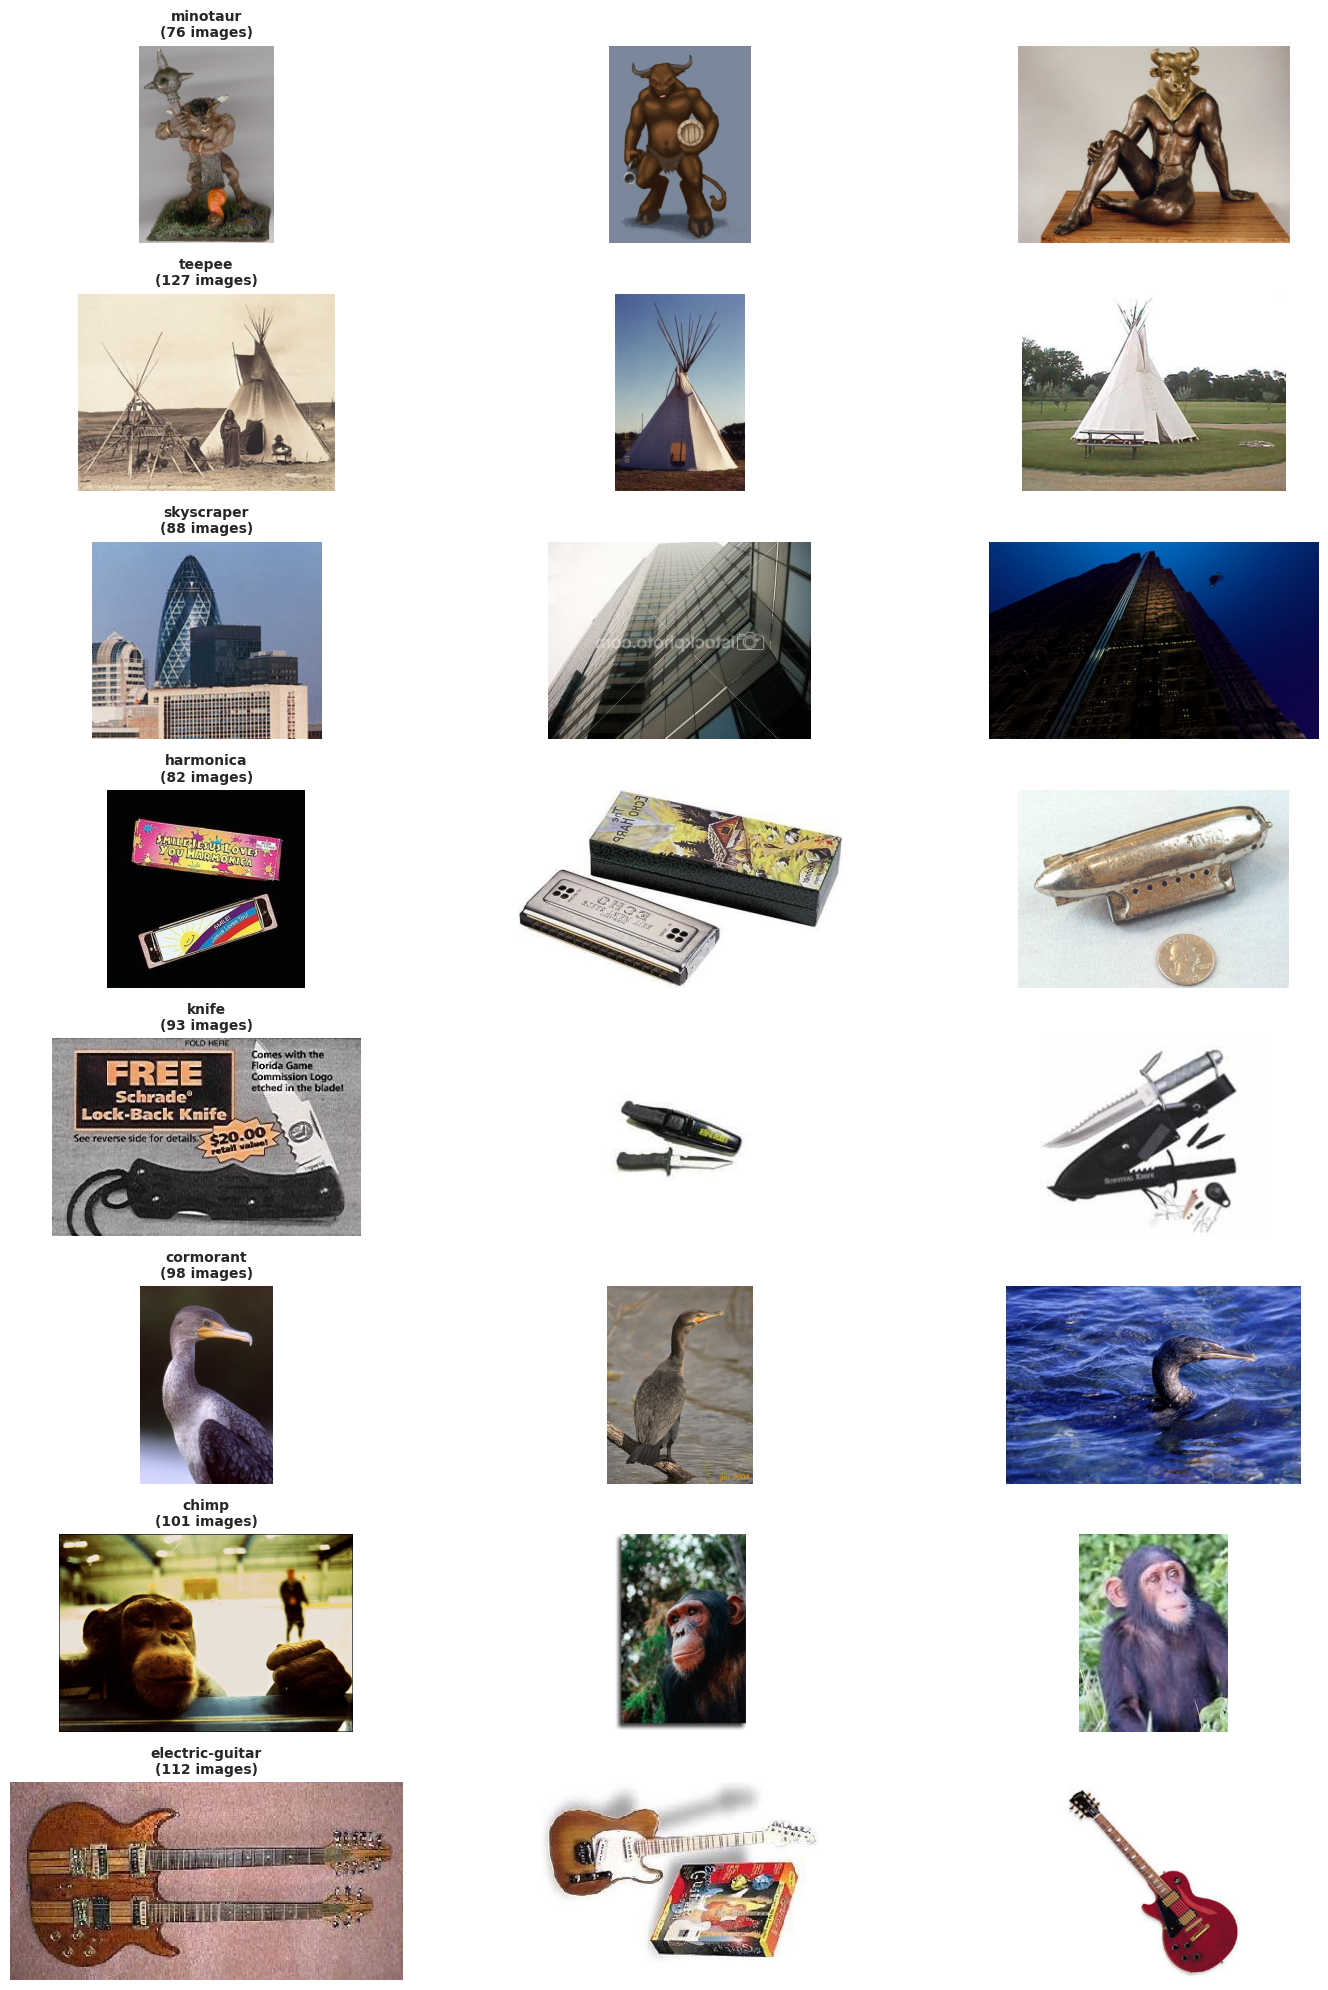


Category Name Analysis:
Shortest category name: 'cd' (2 chars)
Longest category name: 'self-propelled-lawn-mower' (25 chars)

All categories (233 total):
['airplanes', 'ak47', 'american-flag', 'backpack', 'baseball-glove', 'bat', 'bathtub', 'bear', 'billiards', 'binoculars', 'birdbath', 'blimp', 'bonsai', 'boom-box', 'bowling-ball', 'bowling-pin', 'boxing-glove', 'brain', 'breadmaker', 'buddha', 'bulldozer', 'butterfly', 'cactus', 'cake', 'calculator', 'camel', 'cannon', 'car-side', 'car-tire', 'cartman', 'cd', 'centipede', 'cereal-box', 'chandelier', 'chess-board', 'chimp', 'chopsticks', 'clutter', 'cockroach', 'coffee-mug', 'coffin', 'coin', 'comet', 'computer-keyboard', 'computer-mouse', 'conch', 'cormorant', 'covered-wagon', 'cowboy-hat', 'desk-globe', 'diamond-ring', 'dice', 'dog', 'dolphin-101', 'doorknob', 'drinking-straw', 'duck', 'eiffel-tower', 'electric-guitar', 'elephant', 'elk', 'ewer', 'eyeglasses', 'faces-easy', 'fern', 'fighter-jet', 'fire-extinguisher', 'fire-hydrant'

In [ ]:
# Visualize sample images from different categories
n_categories_to_show = 8
n_images_per_category = 3

# Select random categories
random_categories = np.random.choice(df['category'].unique(),
                                     size=min(n_categories_to_show, df['category'].nunique()),
                                     replace=False)

# Create figure
fig, axes = plt.subplots(n_categories_to_show, n_images_per_category,
                         figsize=(15, 2.5*n_categories_to_show))

if n_categories_to_show == 1:
    axes = axes.reshape(1, -1)

for i, category in enumerate(random_categories):
    # Get images from this category
    category_df = df[df['category'] == category]

    # Sample random images
    sampled_images = category_df.sample(n=min(n_images_per_category, len(category_df)))

    for j, (idx, row) in enumerate(sampled_images.iterrows()):
        img_path = row['image_path']

        try:
            img = Image.open(img_path)

            # Display image
            if n_categories_to_show > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]

            ax.imshow(img)
            ax.axis('off')

            if j == 0:  # Add category label to first image in row
                ax.set_title(f"{category}\n({len(category_df)} images)",
                           fontsize=10, fontweight='bold')

            img.close()

        except Exception as e:
            print(f"Error loading {img_path}: {e}")

plt.tight_layout()
plt.savefig('images/sample_images_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional: Show category name statistics
print("\nCategory Name Analysis:")
print(f"Shortest category name: '{min(df['category'].unique(), key=len)}' ({len(min(df['category'].unique(), key=len))} chars)")
print(f"Longest category name: '{max(df['category'].unique(), key=len)}' ({len(max(df['category'].unique(), key=len))} chars)")
print(f"\nAll categories ({len(df['category'].unique())} total):")
print(sorted(df['category'].unique()))

## Section 2: EDA and Feature Engineering
In Section 2 we perform exploratory data analysis in order to understand the characteristics of our dataset. Specifically, we will carry out:

1. **Visual Feature Extraction** – Extract high-level numerical representations from all images using MobileNetV2, a pre-trained convolutional neural network used here as a feature extractor (transfer learning).

2. **Feature Distribution Analysis** – Analyze the statistical properties of the extracted feature vectors.

3. **Dimensionality Reduction** – Apply methods such as PCA and t-SNE to project high-dimensional feature vectors into 2D or 3D space, enabling visual exploration of clusters and similarities among images.

4. **Category Relationships** – Explore visual similarities and differences between categories.

5. **Data Visualization** – Create comprehensive visualizations to understand patterns, clusters, and potential sources of ambiguity in the dataset.


Due to the fact that our dataset is composed of images, it is convenient to extract features using pre-trained deep neural networks. This approach offers two main advantages:

1. **Pre-trained models have been trained on millions of images**, enabling them to recognize visual patterns far more effectively than traditional handcrafted methods such as HOG (Histogram of Oriented Gradients) and SIFT (Scale-Invariant Feature Transform), which rely on much more limited datasets.

2. **They are computationally more efficient**, because we extract features only once and then reuse them throughout the rest of the pipeline, instead of repeatedly reprocessing pixel data.


The steps we follow to apply MobileNetV2 for feature extraction are the following:

1. **Load the pre-trained model**, but without the final ("top") classification layer, because we only need the feature extractor. The neuron weights are those pre-trained on ImageNet, and we apply **Global Average Pooling (GAP)** to obtain a fixed-size feature vector of length 1280.

2. **Load the images and convert them into NumPy arrays**, allowing us to pass them through the model for feature computation.

3. **Process images in batches of size 32**, which greatly speeds up computation thanks to TensorFlow optimizations and more efficient GPU parallelization compared to processing each image individually.


### Category Distribution Visualization

In [ ]:
top_n = 20
top_counts = category_counts.head(top_n)

y_labels = top_counts.index[::-1]
x_values = top_counts.values[::-1]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=x_values,
        y=y_labels,
        orientation='h'
    )
)

fig.update_layout(
    title=f"Top {top_n} categories by image count",
    xaxis_title="Number of images",
    yaxis_title="Category",
    height=600
)

fig.show()

In [ ]:
bottom_n = 20

bottom_counts = category_counts.tail(bottom_n)

y_labels = bottom_counts.index[::-1]
x_values = bottom_counts.values[::-1]

fig_bottom = go.Figure()

fig_bottom.add_trace(
    go.Bar(
        x=x_values,
        y=y_labels,
        orientation='h'
    )
)

fig_bottom.update_layout(
    title=f"Bottom {bottom_n} categories by image count",
    xaxis_title="Number of images",
    yaxis_title="Category",
    height=600
)

fig_bottom.show()

In [ ]:
# Distribution values
values = category_counts.values

mean_val = np.mean(values)
median_val = np.median(values)

fig_hist = go.Figure()

# Histogram
fig_hist.add_trace(
    go.Histogram(
        x=values,
        nbinsx=30,
        name="Distribution"
    )
)

# Mean line
fig_hist.add_trace(
    go.Scatter(
        x=[mean_val, mean_val],
        y=[0, max(np.histogram(values, bins=30)[0])],
        mode="lines",
        line=dict(color="red", width=2, dash="dash"),
        name=f"Mean ({mean_val:.1f})"
    )
)

# Median line
fig_hist.add_trace(
    go.Scatter(
        x=[median_val, median_val],
        y=[0, max(np.histogram(values, bins=30)[0])],
        mode="lines",
        line=dict(color="blue", width=2, dash="dot"),
        name=f"Median ({median_val:.1f})"
    )
)

fig_hist.update_layout(
    title="Distribution of images per category (with mean & median)",
    xaxis_title="Images per category",
    yaxis_title="Number of categories",
    legend=dict(
        x=0.7, y=0.95,
        bgcolor="rgba(255,255,255,0.5)"
    )
)

fig_hist.show()


In [ ]:
fig_box = go.Figure()

fig_box.add_trace(
    go.Box(
        y=values,
        boxpoints='all',
        jitter=0,
        pointpos=0,
        marker=dict(color='black', size=4),
        line=dict(color='red'),
        fillcolor='rgba(255, 200, 200, 0.3)'
    )
)

fig_box.update_layout(
    title="Box Plot of Category Sizes",
    yaxis_title="Number of images",
    height=500
)

fig_box.show()


In [ ]:
std_val = np.std(values)
min_val = np.min(values)
max_val = np.max(values)
q1 = np.quantile(values, 0.25)
q3 = np.quantile(values, 0.75)

most_common_cat = category_counts.index[0]
most_common_val = category_counts.values[0]

least_common_cat = category_counts.index[-1]
least_common_val = category_counts.values[-1]

imbalance_ratio = max_val / min_val

fig_stats = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=["<b>CATEGORY DISTRIBUTION STATISTICS</b>"],
                fill_color='lightgray',
                align='left',
                font=dict(size=14)
            ),
            cells=dict(
                values=[[
                    f"Total Categories: {len(category_counts)}",
                    f"Total Images: {category_counts.sum():,}",
                    "",
                    "Images per Category:",
                    f"• Mean: {mean_val:.2f}",
                    f"• Median: {median_val:.2f}",
                    f"• Std Dev: {std_val:.2f}",
                    f"• Min: {min_val}",
                    f"• Max: {max_val}",
                    f"• Q1: {q1:.2f}",
                    f"• Q3: {q3:.2f}",
                    "",
                    f"Class Imbalance Ratio: {imbalance_ratio:.2f}x",
                    "",
                    f"Most Common: {most_common_cat} ({most_common_val} images)",
                    f"Least Common: {least_common_cat} ({least_common_val} images)"
                ]],
                align='left',
                font=dict(size=12),
                height=28,
                fill_color='rgb(245, 240, 220)'  # beige come nel main
            )
        )
    ]
)

fig_stats.update_layout(height=700)
fig_stats.show()

### Feature Extraction Using Pre-Trained Model

In [ ]:
# Feature Extraction using MobileNetV2
# Load pre-trained MobileNetV2 model without top classification layer, this is pur feature extractor
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # Remove classification head
    weights='imagenet',
    pooling='avg'  # Global average pooling to get fixed-size feature vector
)

print(f"Feature vector dimension: {base_model.output_shape[1]}")

# Function to preprocess and extract features from an image
def extract_features(img_path, target_size=(224, 224)):
    """Extract features from a single image using MobileNetV2"""
    try:
        # Load and preprocess image
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

        # Extract features
        features = base_model.predict(img_array, verbose=0)
        return features.flatten()
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

# Extract features for all images (with progress tracking)
features_list = []
valid_indices = []
failed_images = []

# Process images in batches for efficiency
batch_size = 32
n_batches = int(np.ceil(len(df) / batch_size))

for batch_idx in range(n_batches):
    start_idx = batch_idx * batch_size
    end_idx = min((batch_idx + 1) * batch_size, len(df))

    batch_images = []
    batch_indices = []

    # Load batch of images
    for idx in range(start_idx, end_idx):
        img_path = df.iloc[idx]['image_path']
        try:
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            batch_images.append(img_array)
            batch_indices.append(idx)
        except Exception as e:
            failed_images.append(img_path)
            continue

    if len(batch_images) > 0:
        # Preprocess batch
        batch_images = np.array(batch_images)
        batch_images = tf.keras.applications.mobilenet_v2.preprocess_input(batch_images)

        # Extract features for batch
        batch_features = base_model.predict(batch_images, verbose=0)

        # Store features and indices
        for i, features in enumerate(batch_features):
            features_list.append(features)
            valid_indices.append(batch_indices[i])

    # Progress update
    if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == n_batches:
        progress = ((batch_idx + 1) / n_batches) * 100
        print(f"Progress: {progress:.1f}% ({batch_idx + 1}/{n_batches} batches) - "
              f"{len(features_list)} images processed")

# Convert to numpy array
features_array = np.array(features_list)

# Create cleaned dataframe with only successfully processed images
df_features = df.iloc[valid_indices].copy().reset_index(drop=True)

print(f"Successfully extracted features from: {len(features_list):,} images")
print(f"Failed to process: {len(failed_images)} images")
print(f"Feature matrix shape: {features_array.shape}")
print(f"{features_array.shape[0]:,} samples")
print(f"{features_array.shape[1]} features per image")
print(f"\nMemory usage: {features_array.nbytes / (1024**2):.2f} MB") # For memory usage which was limited under wsl

2025-11-30 18:44:07.057253: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1764524647.057312   20626 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Feature vector dimension: 1280


2025-11-30 18:44:09.763805: I external/local_xla/xla/service/service.cc:163] XLA service 0x75ef4800f260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-30 18:44:09.763856: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
2025-11-30 18:44:09.808958: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-30 18:44:10.259282: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90700
I0000 00:00:1764524655.313420   20737 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Progress: 1.3% (10/799 batches) - 320 images processed
Progress: 2.5% (20/799 batches) - 640 images processed
Progress: 3.8% (30/799 batches) - 960 images processed
Progress: 5.0% (40/799 batches) - 1280 images processed
Progress: 6.3% (50/799 batches) - 1600 images processed
Progress: 7.5% (60/799 batches) - 1920 images processed
Progress: 8.8% (70/799 batches) - 2240 images processed
Progress: 10.0% (80/799 batches) - 2560 images processed
Progress: 11.3% (90/799 batches) - 2880 images processed
Progress: 12.5% (100/799 batches) - 3200 images processed
Progress: 13.8% (110/799 batches) - 3520 images processed
Progress: 15.0% (120/799 batches) - 3840 images processed
Progress: 16.3% (130/799 batches) - 4160 images processed
Progress: 17.5% (140/799 batches) - 4480 images processed
Progress: 18.8% (150/799 batches) - 4800 images processed
Progress: 20.0% (160/799 batches) - 5120 images processed
Progress: 21.3% (170/799 batches) - 5440 images processed
Progress: 22.5% (180/799 batches)

### Feature Distribution Analysis

With features now represented as numerical vectors, we can analyze their statistical properties:

- **Base statistics** such as mean, standard deviation, and range
- **Correlation** between different feature dimensions
- **Distributions** of feature values across the dataset

This analysis provides insights that guide the next steps in preprocessing:

- Whether **scaling or normalization** is required
- Whether **dimensionality reduction** (PCA, t-SNE) is beneficial
- The overall **complexity and structure** of the feature space


In [ ]:
# Analyze feature distributions
print("Feature Distribution Analysis")

# Basic statistics
feature_means = features_array.mean(axis=0)
feature_stds = features_array.std(axis=0)
feature_mins = features_array.min(axis=0)
feature_maxs = features_array.max(axis=0)

print(f"\nFeature Statistics:")
print(f"  Mean of means: {feature_means.mean():.4f}")
print(f"  Mean of stds:  {feature_stds.mean():.4f}")
print(f"  Global min:    {feature_mins.min():.4f}")
print(f"  Global max:    {feature_maxs.max():.4f}")

# Create comprehensive visualizations

# 1. Distribution of feature means
fig_means = go.Figure()
fig_means.add_trace(
    go.Histogram(
        x=feature_means,
        nbinsx=50
    )
)

fig_means.update_layout(
    title="Distribution of feature means across features",
    xaxis_title="Mean activation value",
    yaxis_title="Number of features"
)

fig_means.show()

# 2. Distribution of feature standard deviations
fig_stds = go.Figure()
fig_stds.add_trace(
    go.Histogram(
        x=feature_stds,
        nbinsx=50
    )
)

fig_stds.update_layout(
    title="Distribution of feature standard deviations",
    xaxis_title="Standard deviation of feature activation",
    yaxis_title="Number of features"
)

fig_stds.show()

# 3. Distribution of feature ranges
feature_ranges = feature_maxs - feature_mins

fig_ranges = go.Figure()
fig_ranges.add_trace(
    go.Histogram(
        x=feature_ranges,
        nbinsx=50
    )
)

fig_ranges.update_layout(
    title="Distribution of feature ranges (max - min)",
    xaxis_title="Range of activation",
    yaxis_title="Number of features"
)

fig_ranges.show()

# 4. Sample feature values across images (first 100 features)
n_features_sample = 100
n_images_sample = min(200, features_array.shape[0])

sample_matrix = features_array[:n_images_sample, :n_features_sample]

fig_sample_feat = go.Figure(
    data=go.Heatmap(
        z=sample_matrix,
        colorbar=dict(title="Activation")
    )
)

fig_sample_feat.update_layout(
    title=f"Activations of first {n_features_sample} features across {n_images_sample} images",
    xaxis_title="Feature index",
    yaxis_title="Image index"
)

fig_sample_feat.show()

# 5. Feature correlation sample (random subset to avoid memory issues)
subset_size = 50
np.random.seed(RANDOM_STATE)
subset_indices = np.random.choice(features_array.shape[1],
                                  size=subset_size,
                                  replace=False)

subset_features = features_array[:, subset_indices]

corr_matrix = np.corrcoef(subset_features.T)

fig_corr = go.Figure(
    data=go.Heatmap(
        z=corr_matrix,
        colorbar=dict(title="Correlation")
    )
)

fig_corr.update_layout(
    title=f"Correlation matrix of {subset_size} random features",
    xaxis_title="Feature index",
    yaxis_title="Feature index"
)

fig_corr.show()

# 6. Distribution of a few sample features
sample_feat_indices = subset_indices[:4]

fig_sample_distr = go.Figure()

for idx in sample_feat_indices:
    fig_sample_distr.add_trace(
        go.Histogram(
            x=features_array[:, idx],
            opacity=0.5,
            name=f"Feature {idx}"
        )
    )

fig_sample_distr.update_layout(
    title="Activation distribution of sample features",
    xaxis_title="Activation value",
    yaxis_title="Number of images",
    barmode='overlay'
)

fig_sample_distr.show()

# Check for zero-variance features
zero_var_features = np.where(feature_stds < 1e-10)[0]
print(f"\nZero-variance features: {len(zero_var_features)}")
if len(zero_var_features) > 0:
    print(f"  These features have no variation and could be removed")

# Check sparsity
sparsity = (features_array == 0).sum() / features_array.size * 100
print(f"\nFeature sparsity: {sparsity:.2f}% (percentage of zero values)")

Feature Distribution Analysis

Feature Statistics:
  Mean of means: 0.3832
  Mean of stds:  0.5714
  Global min:    0.0000
  Global max:    6.0000

Zero-variance features: 0

Feature sparsity: 28.36% (percentage of zero values)


### Dimension Reduction and Visualisation of High-dimensional features

MobileNetV2 returns high-dimensional feature vectors (1280 values per image), making direct visualization impossible. To explore how images relate to each other in feature space, we must first project these vectors into lower dimensions using **dimensionality reduction** techniques.

For visualization purposes, we use a subset of **5000 samples**, selected through **stratified sampling** to preserve the category proportions of the original dataset.

We then apply two complementary techniques:

1. **PCA (Principal Component Analysis)** – Reduces the feature vectors from 1280 dimensions to 2D or 3D while retaining as much variance as possible. This provides a first global approximation of how the data is structured.

2. **t-SNE (t-distributed Stochastic Neighbor Embedding)** – Focuses on preserving **local relationships**, meaning that points that are close in the original high-dimensional space remain close in the 2D projection. This technique is especially effective at revealing clusters and fine-grained structures.


In [ ]:
# For visualization, we'll use a subset
max_samples_for_viz = 5000
if len(features_array) > max_samples_for_viz:
    print(f"\nDataset has {len(features_array)} samples - using stratified sample of {max_samples_for_viz} for visualization")
    # Stratified sampling to maintain category proportions
    from sklearn.model_selection import train_test_split
    _, X_viz, _, y_viz = train_test_split(
        features_array,
        df_features['category'],
        train_size=(len(features_array) - max_samples_for_viz),
        stratify=df_features['category'],
        random_state=RANDOM_STATE
    )
else:
    X_viz = features_array
    y_viz = df_features['category']

print(f"Visualization sample size: {len(X_viz)} images")

# 1. PCA - Principal Component Analysis
print("\n1. Applying PCA...")
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)

X_pca_2d = pca_2d.fit_transform(X_viz)
X_pca_3d = pca_3d.fit_transform(X_viz)

print(f"PCA 2D: Explained variance: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")
print(f"PCA 3D: Explained variance: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

# 2. t-SNE - T-distributed Stochastic Neighbor Embedding
print("\n2. Applying t-SNE (this may take a few minutes)...")

# Use PCA preprocessing for t-SNE (recommended practice)
pca_50 = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca_50 = pca_50.fit_transform(X_viz)

tsne_2d = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne_2d = tsne_2d.fit_transform(X_pca_50)


# Create visualizations

# Limit categories for color clarity (show top 20 by frequency)
category_counts = pd.Series(y_viz).value_counts()
top_categories = category_counts.head(20).index.tolist()
color_map = {cat: i for i, cat in enumerate(top_categories)}

# Assign colors: top categories get distinct colors, others are gray
colors_pca = [color_map.get(cat, -1) for cat in y_viz]
colors_tsne = colors_pca.copy()

# Create DataFrame for plotting
viz_df = pd.DataFrame({
    'PCA1': X_pca_2d[:, 0],
    'PCA2': X_pca_2d[:, 1],
    'PCA3': X_pca_3d[:, 2],
    'tSNE1': X_tsne_2d[:, 0],
    'tSNE2': X_tsne_2d[:, 1],
    'category': y_viz.values if hasattr(y_viz, 'values') else y_viz,
    'is_top20': [cat in top_categories for cat in y_viz]
})

# 1. PCA 2D Scatter Plot
fig_pca2d = go.Figure()

# Plot non-top categories in gray first (background)
df_other = viz_df[~viz_df['is_top20']]
fig_pca2d.add_trace(go.Scatter(
    x=df_other['PCA1'], y=df_other['PCA2'],
    mode='markers',
    marker=dict(size=4, color='lightgray', opacity=0.3),
    name='Other categories',
    hoverinfo='skip'
))

# Plot top 20 categories with distinct colors
for cat in top_categories:
    df_cat = viz_df[viz_df['category'] == cat]
    fig_pca2d.add_trace(go.Scatter(
        x=df_cat['PCA1'], y=df_cat['PCA2'],
        mode='markers',
        marker=dict(size=6, opacity=0.7),
        name=cat[:20],  # Truncate long names
        hovertemplate=f'<b>{cat}</b><br>PC1: %{{x:.2f}}<br>PC2: %{{y:.2f}}<extra></extra>'
    ))

fig_pca2d.update_layout(
    title=f'PCA 2D Projection ({pca_2d.explained_variance_ratio_.sum()*100:.1f}% variance explained)',
    xaxis_title=f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
    yaxis_title=f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)',
    height=600,
    legend=dict(font=dict(size=9), itemsizing='constant')
)
fig_pca2d.show()

# 2. t-SNE 2D Scatter Plot
fig_tsne = go.Figure()

# Plot non-top categories in gray first
fig_tsne.add_trace(go.Scatter(
    x=df_other['tSNE1'], y=df_other['tSNE2'],
    mode='markers',
    marker=dict(size=4, color='lightgray', opacity=0.3),
    name='Other categories',
    hoverinfo='skip'
))

# Plot top 20 categories
for cat in top_categories:
    df_cat = viz_df[viz_df['category'] == cat]
    fig_tsne.add_trace(go.Scatter(
        x=df_cat['tSNE1'], y=df_cat['tSNE2'],
        mode='markers',
        marker=dict(size=6, opacity=0.7),
        name=cat[:20],
        hovertemplate=f'<b>{cat}</b><br>tSNE1: %{{x:.2f}}<br>tSNE2: %{{y:.2f}}<extra></extra>'
    ))

fig_tsne.update_layout(
    title='t-SNE 2D Projection (Local Structure Preserved)',
    xaxis_title='t-SNE Dimension 1',
    yaxis_title='t-SNE Dimension 2',
    height=600,
    legend=dict(font=dict(size=9), itemsizing='constant')
)
fig_tsne.show()

# 3. PCA 3D Interactive Plot
fig_pca3d = go.Figure()

for cat in top_categories[:10]:  # Limit to 10 for 3D clarity
    df_cat = viz_df[viz_df['category'] == cat]
    fig_pca3d.add_trace(go.Scatter3d(
        x=df_cat['PCA1'], y=df_cat['PCA2'], z=df_cat['PCA3'],
        mode='markers',
        marker=dict(size=4, opacity=0.7),
        name=cat[:20],
        hovertemplate=f'<b>{cat}</b><extra></extra>'
    ))

fig_pca3d.update_layout(
    title='PCA 3D Projection (Top 10 Categories)',
    scene=dict(
        xaxis_title=f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)'
    ),
    height=600
)
fig_pca3d.show()

# 4. Explained Variance Plot
pca_full = PCA(n_components=50, random_state=RANDOM_STATE)
pca_full.fit(X_viz)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig_var = go.Figure()
fig_var.add_trace(go.Bar(
    x=list(range(1, 51)),
    y=pca_full.explained_variance_ratio_ * 100,
    name='Individual',
    marker_color='#2E86DE'
))
fig_var.add_trace(go.Scatter(
    x=list(range(1, 51)),
    y=cumulative_var,
    mode='lines+markers',
    name='Cumulative',
    line=dict(color='#EE5A6F', width=2)
))

# Add threshold line at 90%
fig_var.add_hline(y=90, line_dash="dash", line_color="green",
                  annotation_text="90% threshold")

n_components_90 = np.argmax(cumulative_var >= 90) + 1
fig_var.update_layout(
    title=f'PCA Explained Variance (90% at {n_components_90} components)',
    xaxis_title='Principal Component',
    yaxis_title='Explained Variance (%)',
    height=450,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)
fig_var.show()

print(f"PCA Analysis:")
print(f"First 2 components capture: {pca_2d.explained_variance_ratio_.sum()*100:.2f}% of variance")
print(f"First 3 components capture: {pca_3d.explained_variance_ratio_.sum()*100:.2f}% of variance")


Dataset has 25557 samples - using stratified sample of 5000 for visualization
Visualization sample size: 5000 images

1. Applying PCA...
PCA 2D: Explained variance: 5.12%
PCA 3D: Explained variance: 6.77%

2. Applying t-SNE (this may take a few minutes)...
PCA Analysis:
First 2 components capture: 5.12% of variance
First 3 components capture: 6.77% of variance


## Section 3: Data Preprocessing
We prepare our data for model training by applying several preprocessing steps:

1. **Label Encoding** – Converts categorical labels into numerical values so that machine learning models and neural networks can work with them.

2. **Feature Scaling** – Standardizes the extracted features to ensure that all dimensions contribute proportionally, preventing features with larger numeric ranges from dominating the training process.

3. **Train/Validation/Test Split** – Separates the dataset into training (for model learning), validation (for hyperparameter tuning), and test sets (for final evaluation), ensuring a fair and reliable assessment of model performance.


**Label Encoding and Feature Scaling**

First, we apply **LabelEncoder**, which transforms categorical labels (the category names) into numerical values. Neural networks and most machine learning algorithms cannot work directly with text, so converting categories into integers is a necessary preprocessing step.

Next, we apply **StandardScaler** to the extracted features. This preprocessing step ensures that every feature has mean 0 and standard deviation 1. Standardization is essential because some features may naturally have larger numerical ranges than others; without scaling, these features would dominate the learning process, distort distance-based methods, and negatively affect both clustering and neural network training.


In [ ]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_features['category'])

print(f"\nLabel Encoding:")
print(f"  Number of classes: {len(label_encoder.classes_)}")
print(f"  Classes: {label_encoder.classes_[:10]}..." if len(label_encoder.classes_) > 10 else f"  Classes: {label_encoder.classes_}")

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_array)

print(f"\nFeature Scaling:")
print(f"  Original features - Mean: {features_array.mean():.4f}, Std: {features_array.std():.4f}")
print(f"  Scaled features   - Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")


Label Encoding:
  Number of classes: 233
  Classes: ['airplanes' 'ak47' 'american-flag' 'backpack' 'baseball-glove' 'bat'
 'bathtub' 'bear' 'billiards' 'binoculars']...

Feature Scaling:
  Original features - Mean: 0.3832, Std: 0.5876
  Scaled features   - Mean: 0.0000, Std: 1.0000


### Train/Validation/Test Split

We divide the dataset in two steps.

First, we create a **test set (15%)**, keeping it completely separate for the final evaluation.
Then, we split the remaining data again to obtain a **validation set (15%)**, leaving the rest as the final **training set (70%)**.

All splits are **stratified**, meaning the proportion of categories is preserved in each subset.
This is essential because the dataset is highly imbalanced, and stratification ensures that all classes appear in each split with consistent frequencies.


In [ ]:
# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.15,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

# Second split: separate validation set from remaining data (15% of total = ~17.6% of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # This gives us 15% of the original data
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"\nDataset Splits:")
print(f"  Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"  Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"  Total:          {len(X_scaled):,} samples")

# Verify class distribution
print(f"\nClass Distribution Verification:")
print(f"  Original:   {np.bincount(y_encoded).min()} to {np.bincount(y_encoded).max()} samples per class")
print(f"  Training:   {np.bincount(y_train).min()} to {np.bincount(y_train).max()} samples per class")
print(f"  Validation: {np.bincount(y_val).min()} to {np.bincount(y_val).max()} samples per class")
print(f"  Test:       {np.bincount(y_test).min()} to {np.bincount(y_test).max()} samples per class")


Dataset Splits:
  Training set:   17,899 samples (70.0%)
  Validation set: 3,824 samples (15.0%)
  Test set:       3,834 samples (15.0%)
  Total:          25,557 samples

Class Distribution Verification:
  Original:   72 to 761 samples per class
  Training:   50 to 533 samples per class
  Validation: 11 to 114 samples per class
  Test:       11 to 114 samples per class


## Section 4: Clustering

Now we apply two different clustering algorithms: **K-Means** and **Hierarchical Clustering**.
We set the number of clusters to **233**, equal to the number of categories in the dataset.

To evaluate their performance, we use three complementary metrics:

**Silhouette Score**: measures how compact and well-separated the clusters are.
Values range from **-1 to 1**, where:
- **1** → perfectly separated clusters
- **0** → overlapping clusters
- **-1** → incorrect clustering structure

**NMI — Normalized Mutual Information**: measures how much information the predicted clusters share with the true labels.
Values range from **0 to 1**, where **1** means perfect agreement.

**ARI — Adjusted Rand Index**: measures how well the clustering reproduces the exact distribution of the true categories.
Values range from **-1 to 1**, where **1** indicates perfect correspondence.


In [ ]:
# Number of clusters = number of categories
n_clusters = 233

# K-Means Clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

km_silhouette = silhouette_score(X_scaled, kmeans_labels)
km_nmi = normalized_mutual_info_score(y_encoded, kmeans_labels)
km_ari = adjusted_rand_score(y_encoded, kmeans_labels)

# Hierarchical Clustering
hier = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

hier_silhouette = silhouette_score(X_scaled, hier_labels)
hier_nmi = normalized_mutual_info_score(y_encoded, hier_labels)
hier_ari = adjusted_rand_score(y_encoded, hier_labels)

# VISUALISATIONS
# Comparison of clustering metrics (silhouette, NMI, ARI)
fig_cluster = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Cluster Cohesion (Silhouette)', 'Label Correspondence (NMI/ARI)'),
    specs=[[{"type": "bar"}, {"type": "bar"}]]
)

# Silhouette comparison
fig_cluster.add_trace(
    go.Bar(
        x=['K-Means', 'Hierarchical'],
        y=[km_silhouette, hier_silhouette],
        text=[f'{km_silhouette:.4f}', f'{hier_silhouette:.4f}'],
        textposition='auto',
        marker_color=['#2E86DE', '#27AE60'],
        name='Silhouette Score'
    ),
    row=1, col=1
)

# NMI and ARI comparison
fig_cluster.add_trace(
    go.Bar(
        x=['K-Means NMI', 'Hier NMI', 'K-Means ARI', 'Hier ARI'],
        y=[km_nmi, hier_nmi, km_ari, hier_ari],
        text=[f'{km_nmi:.4f}', f'{hier_nmi:.4f}', f'{km_ari:.4f}', f'{hier_ari:.4f}'],
        textposition='auto',
        marker_color=['#2E86DE', '#27AE60', '#2E86DE', '#27AE60'],
        name='Agreement Metrics'
    ),
    row=1, col=2
)

fig_cluster.update_layout(
    height=400,
    title_text='Clustering Algorithm Comparison',
    showlegend=False
)
fig_cluster.update_yaxes(title_text="Score", row=1, col=1)
fig_cluster.update_yaxes(title_text="Score", row=1, col=2)

fig_cluster.show()

### **Clustering Analysis Summary**

We observe a strong presence of **overlapping clusters**, clearly visible in the visualization and confirmed by the **very low Silhouette Score**.
The **NMI score is relatively high**, meaning the clusters still capture some useful information about the dataset, but the **ARI score is mediocre**, indicating that the clustering does **not** reproduce the true category structure effectively.

Some categories form well-defined clusters—specifically those with strong visual uniqueness—while many others overlap almost completely.

Two major dataset characteristics contribute to this limited separability:

- **~28% zero entries in the feature vectors**, which reduce the discriminative power of the extracted features
- **Strong class imbalance**, which biases the clustering process toward larger classes

Overall, the combination of sparsity, imbalance, and high category count makes the dataset extremely challenging to cluster accurately.

In [ ]:
# NEW: Visualisations for interpreted clusters and accuracy metrics

Analysis of interpreted clusters and accuracy

## Section 5: Deep Learning

First we start with a CNN using the raw data with balanced classes then we switch to an ANN approach using the feature extracted with MobileNetV2.

### CNN Model Architecture and Data Preparation

Now we'll build a Convolutional Neural Network (CNN) that works directly with the original image data (without pre-extracted MobileNet features). This allows the network to learn its own visual representations from scratch.
We first retrieve a list of all the feature indices, then we do again stratified sampling in order to divide them into training (70%), validation (15%) and test (15%) and keep the same proportions as in the original dataset. We then create a data generator that will give the model the “recipe” that it will follow to process the photos (rescaling to [0,1], shifting and filling method). We then process the datas in batches while shuffling them each time (in order to avoid that the model “memorizes” the order)


In [ ]:
# Reconstruct train/val/test splits matching splits from earlier
temp_indices = list(range(len(features_array)))
train_temp_indices, test_temp_indices = train_test_split(
    temp_indices, test_size=0.15, stratify=y_encoded, random_state=RANDOM_STATE
)
train_final_indices, val_final_indices = train_test_split(
    train_temp_indices, test_size=0.176, stratify=y_encoded[train_temp_indices], random_state=RANDOM_STATE
)

# Create DataFrames for each split
df_train_cnn = df_features.iloc[train_final_indices].copy()
df_val_cnn = df_features.iloc[val_final_indices].copy()
df_test_cnn = df_features.iloc[test_temp_indices].copy()

print(f"   Train: {len(df_train_cnn):,} samples")
print(f"   Val:   {len(df_val_cnn):,} samples")
print(f"   Test:  {len(df_test_cnn):,} samples")

# Image parameters (standard input size)
IMG_HEIGHT = 128
IMG_WIDTH = 128
CNN_BATCH_SIZE = 16

print(f"\nImage configuration:")
print(f"   Input shape: ({IMG_HEIGHT}, {IMG_WIDTH}, 3)")
print(f"   Batch size: {CNN_BATCH_SIZE}")

# DATA AUGMENTATION for training set (Regularization)
print("\nRegularising data...")
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0,1]
    rotation_range=20,           # Random rotation ±20°
    width_shift_range=0.2,       # Horizontal shift ±20%
    height_shift_range=0.2,      # Vertical shift ±20%
    horizontal_flip=True,        # Random horizontal flip
    zoom_range=0.2,              # Random zoom ±20%
    fill_mode='nearest'          # Fill pixels after transforms
)

# Validation/test set: only rescaling (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)


# Get exact class ordering from label encoder
class_list = list(label_encoder.classes_)
print(f"\nUsing {len(class_list)} classes from label encoder")
print(f"   First 5 classes: {class_list[:5]}")

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    df_train_cnn,
    x_col='image_path',
    y_col='category',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=CNN_BATCH_SIZE,
    class_mode='categorical',
    classes=class_list,
    shuffle=True,
)

val_generator = val_test_datagen.flow_from_dataframe(
    df_val_cnn,
    x_col='image_path',
    y_col='category',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=CNN_BATCH_SIZE,
    class_mode='categorical',
    classes=class_list,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    df_test_cnn,
    x_col='image_path',
    y_col='category',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=CNN_BATCH_SIZE,
    class_mode='categorical',
    classes=class_list,
    shuffle=False
)


def build_cnn_model(input_shape, num_classes):
    """
    Builds CNN keeping in mind memory limitations
    Key design decisions:
    1. 3 blocks instead of 4: Reduces overfitting risk with limited data
    2. Start at 64 filters: Provides adequate feature capacity
    3. No early dropout: Allows early layers to learn freely
    4. Single dense layer: GAP already provides rich features
    5. Lower learning rate: More stable with larger batches
    """
    model = models.Sequential(name='CNN')

    # Block 1: Low-level features (64 filters)
    # Starting at 64 provides adequate capacity for
    # fine-grained 233-class discrimination. No dropout here allows early
    # layers to learn universal edge/texture detectors without interference.
    model.add(layers.Conv2D(64, (3, 3), padding='same',
                           kernel_initializer='he_normal',
                           input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3, 3), padding='same',
                           kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    # NO DROPOUT: Early layers learn universal features

    # Block 2: Mid-level features (128 filters)
    # JUSTIFICATION: Light dropout (0.2) begins regularization without
    # excessive interference with feature learning.
    model.add(layers.Conv2D(128, (3, 3), padding='same',
                           kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3, 3), padding='same',
                           kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))  # Light dropout

    # Block 3: High-level features (256 filters)
    # 3 blocks sufficient for 224x224 input (receptive field
    # covers significant portion of image). Moderate dropout (0.3) prevents
    # overfitting in deeper layers.
    model.add(layers.Conv2D(256, (3, 3), padding='same',
                           kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3, 3), padding='same',
                           kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))


    # Global Average Pooling
    # JUSTIFICATION: Better than Flatten for CNNs - reduces parameters
    # dramatically and provides translation invariance.
    model.add(layers.GlobalAveragePooling2D())


    # Single Dense Layer (simplified head)
    # JUSTIFICATION: GAP already provides rich 256-dim features. Deep dense
    # heads (512→256) overfit with limited data. Single layer is sufficient.
    model.add(layers.Dense(256, kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.4))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))


    # Learning rate 0.0005 (half of default 0.001) provides
    # more stable training with larger batch sizes. Adam optimizer handles
    # per-parameter learning rates automatically.
    optimizer = Adam(learning_rate=0.0005)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


cnn_model = build_cnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=233
)

# Print model summary
cnn_model.summary()

# TRAINING CALLBACKS
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12,  # Slightly reduced for faster experimentation
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_cnn_optimized.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# ReduceLROnPlateau - KEY for escaping local minima
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Reduce LR by half
    patience=4,       # Wait 4 epochs before reducing
    min_lr=1e-7,      # Don't go below this
    verbose=1
)

   Train: 17,899 samples
   Val:   3,824 samples
   Test:  3,834 samples

Image configuration:
   Input shape: (128, 128, 3)
   Batch size: 16

Regularising data...

Using 233 classes from label encoder
   First 5 classes: ['airplanes', 'ak47', 'american-flag', 'backpack', 'baseball-glove']
Found 17899 validated image filenames belonging to 233 classes.
Found 3824 validated image filenames belonging to 233 classes.
Found 3834 validated image filenames belonging to 233 classes.


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             

 Total params: 1,275,689 (4.87 MB)

 Trainable params: 1,273,385 (4.86 MB)

 Non-trainable params: 2,304 (9.00 KB)

In order to create the CNN we used a **sequential model**, that is, in this case more optimal than  a Functional one, because we need to implement a “sequence” of layers **without any complex ramifications**.  The first block contains **seven layers** and in the first one it applies **64 filters**, each one **3x3**, in order to extract the first patterns from the image. We also use **padding** in order to avoid that the images becoming smaller and smaller with each processing and our kernel initializer is **“he_normal”** that optimizes relu activation functions by avoiding that zero neurons stay constantly turned off. The second one applies batch normalization in order to stabilize learning and normalize convolutional output. We use as a an activation function **RELU**, because it better captures gradients and it is also more optimized for the GPU, since it discards all the negative value while only keeping the positive ones compared to sigmoid or tanh. After repeating the same sequence of layers we apply **maxpooling** that reduces the 128x128 image to a 64x64, reducing the noise and only keeping the most important features and making the model more robust to shifting with **less risk of overfitting**. Block two and three follow the same structure of the first one but they look for respectively mid and high level features with 128 and 256 filters each. Also, in order to avoid overfitting and make the model more able to generalize, we also turn off **30% and 40%** of the neurons in block 2 and three. Finally, since we need to return the most likely category of the image, the final output layer has softmax activation function. Due to larger batch size we put a lower learning rate (**only 0,0005**) that is the half of the conventional 0,001 and we use Adam as an optimizer.  This CNN will take a long time to train due to its complexity and datasize and due to the **limited size of the dataset** (25000 photos) for so many categories.

### CNN Training

In [ ]:
# Setup TensorBoard logging
log_dir = "logs/cnn/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard = TensorBoard(
    log_dir=log_dir,
    histogram_freq=0,
    write_graph=False,
    write_images=False,
    update_freq='epoch',
    profile_batch=0
)

# Memory Management
gc.collect()
tf.keras.backend.clear_session()

# Rebuild model after clearing session
cnn_model = build_cnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=233
)

# Train CNN model
cnn_history = cnn_model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr,
        tensorboard
    ],
    verbose=1
)

# Print final metrics
final_train_acc = cnn_history.history['accuracy'][-1]
final_val_acc = cnn_history.history['val_accuracy'][-1]
final_train_loss = cnn_history.history['loss'][-1]
final_val_loss = cnn_history.history['val_loss'][-1]

print(f"\nFinal Metrics:")
print(f"  Training Accuracy:   {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Training Loss:       {final_train_loss:.4f}")
print(f"  Validation Loss:     {final_val_loss:.4f}")

Epoch 1/40
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.0521 - loss: 5.3727
Epoch 1: val_loss improved from inf to 5.28554, saving model to best_cnn_optimized.keras
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 277s 236ms/step - accuracy: 0.0521 - loss: 5.3725 - val_accuracy: 0.0939 - val_loss: 5.2855 - learning_rate: 5.0000e-04
Epoch 2/40
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.1013 - loss: 4.7648
Epoch 2: val_loss improved from 5.28554 to 4.50086, saving model to best_cnn_optimized.keras
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 245s 219ms/step - accuracy: 0.1013 - loss: 4.7647 - val_accuracy: 0.1331 - val_loss: 4.5009 - learning_rate: 5.0000e-04
Epoch 3/40
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.1184 - loss: 4.5660
Epoch 3: val_loss did not improve from 4.50086
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 155s 138ms/step - accuracy: 0.1184 - loss: 4.5660 - val_accuracy: 0.1211 - val_loss: 4.6576 - learning_rate: 5.0000e-04
Epoch 4/40
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 0s 129

After a **pretty long training**, one hour and a half, and countless try of optimization the best we could obtain was a **45%** on **Training Accuracy** and **43%** **validation accuracy**. The reason lies in the said small dataset and, as we will see, in the same CNN approach, since the extraction with a better pre trained	 model like MobileNetV2 completely outperforms it. We will use the feature extracted to train an **ANN** and see how much accuracy we can get.

CNN Training Visualisation

In [ ]:
# Prepare data
history_df = pd.DataFrame(cnn_history.history)
history_df['epoch'] = range(1, len(history_df) + 1)

# Create subplots: 2 rows, 2 columns
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Training and Validation Accuracy',
        'Training and Validation Loss',
        'Accuracy Comparison',
        'Loss Comparison'
    ),
    specs=[
        [{"secondary_y": False}, {"secondary_y": False}],
        [{"type": "bar"}, {"type": "bar"}]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# Plot 1: Accuracy over epochs (line chart)
fig.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['accuracy'],
        mode='lines+markers',
        name='Training Accuracy',
        line=dict(color='#2E86DE', width=2),
        marker=dict(size=6)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['val_accuracy'],
        mode='lines+markers',
        name='Validation Accuracy',
        line=dict(color='#EE5A6F', width=2),
        marker=dict(size=6)
    ),
    row=1, col=1
)

# Plot 2: Loss over epochs (line chart)
fig.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['loss'],
        mode='lines+markers',
        name='Training Loss',
        line=dict(color='#2E86DE', width=2),
        marker=dict(size=6),
        showlegend=False
    ),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['val_loss'],
        mode='lines+markers',
        name='Validation Loss',
        line=dict(color='#EE5A6F', width=2),
        marker=dict(size=6),
        showlegend=False
    ),
    row=1, col=2
)

# Plot 3: Final accuracy comparison (bar chart)
fig.add_trace(
    go.Bar(
        x=['Training', 'Validation'],
        y=[final_train_acc, final_val_acc],
        text=[f'{final_train_acc:.4f}', f'{final_val_acc:.4f}'],
        textposition='auto',
        marker=dict(color=['#2E86DE', '#EE5A6F']),
        showlegend=False
    ),
    row=2, col=1
)

# Plot 4: Final loss comparison (bar chart)
fig.add_trace(
    go.Bar(
        x=['Training', 'Validation'],
        y=[final_train_loss, final_val_loss],
        text=[f'{final_train_loss:.4f}', f'{final_val_loss:.4f}'],
        textposition='auto',
        marker=dict(color=['#2E86DE', '#EE5A6F']),
        showlegend=False
    ),
    row=2, col=2
)

# Update layout
fig.update_xaxes(title_text="Epoch", row=1, col=1)
fig.update_xaxes(title_text="Epoch", row=1, col=2)
fig.update_xaxes(title_text="Metric Type", row=2, col=1)
fig.update_xaxes(title_text="Metric Type", row=2, col=2)

fig.update_yaxes(title_text="Accuracy", row=1, col=1)
fig.update_yaxes(title_text="Loss", row=1, col=2)
fig.update_yaxes(title_text="Accuracy", row=2, col=1)
fig.update_yaxes(title_text="Loss", row=2, col=2)

fig.update_layout(
    height=800,
    title_text="CNN Training Performance Metrics",
    title_font_size=20,
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    hovermode='x unified'
)

fig.show()

# Create a detailed single-line accuracy plot
fig_acc = go.Figure()

fig_acc.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['accuracy'],
        mode='lines+markers',
        name='Training Accuracy',
        line=dict(color='#2E86DE', width=3),
        marker=dict(size=8, symbol='circle'),
        hovertemplate='<b>Epoch %{x}</b><br>Training Accuracy: %{y:.4f}<extra></extra>'
    )
)

fig_acc.add_trace(
    go.Scatter(
        x=history_df['epoch'],
        y=history_df['val_accuracy'],
        mode='lines+markers',
        name='Validation Accuracy',
        line=dict(color='#EE5A6F', width=3),
        marker=dict(size=8, symbol='diamond'),
        hovertemplate='<b>Epoch %{x}</b><br>Validation Accuracy: %{y:.4f}<extra></extra>'
    )
)

# Add annotations for best performance
best_val_acc_idx = history_df['val_accuracy'].idxmax()
best_val_acc = history_df.loc[best_val_acc_idx, 'val_accuracy']
best_epoch = history_df.loc[best_val_acc_idx, 'epoch']

fig_acc.add_annotation(
    x=best_epoch,
    y=best_val_acc,
    text=f'Best: {best_val_acc:.4f}<br>Epoch {best_epoch}',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='#EE5A6F',
    ax=-50,
    ay=-40,
    bgcolor='rgba(255, 255, 255, 0.8)',
    bordercolor='#EE5A6F',
    borderwidth=2
)

fig_acc.update_layout(
    title='CNN Model Accuracy Over Training Epochs',
    title_font_size=18,
    xaxis_title='Epoch',
    yaxis_title='Accuracy',
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='Black',
        borderwidth=1
    )
)

fig_acc.show()

Description and explanantion of how bad CNN is and why. a

Introduction of ANN using features extracted earlier (and how those features leveraged spacial locality)

### Feature-based ANN: Architecture and Preparation

In [ ]:
# --- Constants ---
FEATURE_DIMENSION = 1280
NB_CATEGORIES = 233     # Number of folders in dataset
EPOCHS = 50
BATCH_SIZE = 64
PATIENCE = 10
OPTIMIZER = tf.keras.optimizers.Adam(learning_rate=0.001)

print(f"Feature Dimension: {FEATURE_DIMENSION}")
print(f"Number of Categories: {NB_CATEGORIES}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# Convert integer labels to one-hot encoding for Softmax output layer
y_train_one_hot = to_categorical(y_train, NB_CATEGORIES)
y_val_one_hot = to_categorical(y_val, NB_CATEGORIES)
y_test_one_hot = to_categorical(y_test, NB_CATEGORIES)

print(f"\nOne-hot encoded label shapes:")
print(f"y_train_one_hot: {y_train_one_hot.shape}")
print(f"y_val_one_hot: {y_val_one_hot.shape}")
print(f"y_test_one_hot: {y_test_one_hot.shape}")

# MODEL DEFINITION: Deep Dense Network (PatternMind Architecture)
def build_patternmind_net(input_dim, classes):
    """
    Builds a deep dense network for high-dimensional feature classification.

    Architecture Design:
    - Layer 1 (512 units): High capacity to capture complex feature interactions
    - Layer 2 (256 units): Medium capacity for intermediate representations
    - Layer 3 (128 units): Lower capacity to consolidate learned patterns
    - Output Layer (softmax): Multi-class probability distribution

    Regularization:
    - BatchNormalization: Stabilizes training by normalizing layer inputs
    - Dropout (0.5, 0.3): Prevents overfitting by randomly dropping connections

    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential(name="PatternMind_ANN")

    # Layer 1: High capacity hidden layer
    model.add(Dense(units=512, activation='relu', input_shape=(input_dim,)))
    model.add(BatchNormalization())  # Stabilize training
    model.add(Dropout(0.5))          # Prevent overfitting

    # Layer 2: Medium capacity hidden layer
    model.add(Dense(units=256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    # Layer 3: Lower capacity layer
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.3))

    # Output Layer (Softmax for multi-class probability distribution)
    model.add(Dense(units=classes, activation='softmax', name='output_classification'))

    return model

# Build the model
patternmind_model = build_patternmind_net(FEATURE_DIMENSION, NB_CATEGORIES)

# Print Model Summary
patternmind_model.summary()

# COMPILATION AND TRAINING SETUP
patternmind_model.compile(
    optimizer=OPTIMIZER,
    loss='categorical_crossentropy',  # Standard loss for multi-class classification
    metrics=['accuracy']
)

# Early Stopping callback to halt training when validation loss plateaus
es_callback = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss
    patience=PATIENCE,         # Wait 10 epochs before stopping
    restore_best_weights=True, # Restore weights from best epoch
    verbose=1
)

print("Model Architecture Defined and Compiled.")
print(f"\nTraining Configuration:")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Loss Function: Categorical Crossentropy")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Max Epochs: {EPOCHS}")
print(f"  Early Stopping Patience: {PATIENCE} epochs")

Feature Dimension: 1280
Number of Categories: 233
Training samples: 17899
Validation samples: 3824
Test samples: 3834

One-hot encoded label shapes:
y_train_one_hot: (17899, 233)
y_val_one_hot: (3824, 233)
y_test_one_hot: (3834, 233)


Model: "PatternMind_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_classification (Dense)   │ (None, 233)            │        30,057 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 853,225 (3.25 MB)

 Trainable params: 851,689 (3.25 MB)

 Non-trainable params: 1,536 (6.00 KB)

Model Architecture Defined and Compiled.

Training Configuration:
  Optimizer: Adam (lr=0.001)
  Loss Function: Categorical Crossentropy
  Batch Size: 64
  Max Epochs: 50
  Early Stopping Patience: 10 epochs


Description of Neural net layers, purpose and how they work...

### ANN Training

In [ ]:
history = patternmind_model.fit(
    X_train, y_train_one_hot,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_one_hot),
    callbacks=[es_callback],
    verbose=1
)

Epoch 1/50


2025-11-30 21:17:14.347632: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:17:14.348578: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:17:14.348625: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:17:14.348647: I external/l

276/280 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1195 - loss: 4.9588

2025-11-30 21:17:26.276119: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:17:26.276171: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:17:26.276188: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:17:26.276201: I external/l

280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1208 - loss: 4.9481

2025-11-30 21:17:37.195213: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:17:38.807257: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_119', 208 bytes spill stores, 208 bytes spill loads

2025-11-30 21:17:39.941352: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:17:39.941420: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were f

280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.1211 - loss: 4.9455 - val_accuracy: 0.5805 - val_loss: 2.1840
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4251 - loss: 2.6153 - val_accuracy: 0.6953 - val_loss: 1.3087
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5695 - loss: 1.8186 - val_accuracy: 0.7356 - val_loss: 1.1113
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6179 - loss: 1.5356 - val_accuracy: 0.7510 - val_loss: 1.0276
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6532 - loss: 1.3472 - val_accuracy: 0.7633 - val_loss: 0.9973
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6908 - loss: 1.2013 - val_accuracy: 0.7652 - val_loss: 0.9760
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7039 - loss: 1.1269 - val_accuracy: 0.7730 - val_loss: 0.9623
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7286 - loss: 1.0169 - val_accuracy: 0.7707 - va

### ANN Training Visualisation

In [ ]:
# questa tocca a te lapo

### Comparing all models (K-means, Heirarchical, CNN, Feature-based ANN)

In [ ]:
# pure questa tocca a te lapo

### Evaluation and Analysis (most important section)

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = patternmind_model.evaluate(X_test, y_test_one_hot, verbose=0)

print("TEST SET EVALUATION")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")


# Get predictions
y_pred_probs = patternmind_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get category names for the report
category_names = label_encoder.classes_

# Generate classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=category_names,
    digits=4
)

print(report)

2025-11-30 21:18:16.165214: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:18:16.165284: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-30 21:18:17.891249: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_119', 12 bytes spill stores, 12 bytes spill loads

2025-11-30 21:18:17.965399: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

TEST SET EVALUATION
Test Accuracy: 0.7723
Test Loss:     0.9403
                           precision    recall  f1-score   support

                airplanes     0.9369    0.9630    0.9498       108
                     ak47     0.6250    0.7692    0.6897        13
            american-flag     0.8182    0.6923    0.7500        13
                 backpack     0.8000    0.7619    0.7805        21
           baseball-glove     0.7727    0.8095    0.7907        21
                      bat     0.5000    0.6000    0.5455        15
                  bathtub     0.8529    0.9062    0.8788        32
                     bear     0.8182    0.6429    0.7200        14
                billiards     0.9167    0.8684    0.8919        38
               binoculars     0.8125    0.8966    0.8525        29
                 birdbath     0.8750    0.5385    0.6667        13
                    blimp     0.9167    0.9167    0.9167        12
                   bonsai     0.7368    0.8235    0.7778        

### Confusion Matricies

We visualise all confusion matricies and see where they overlap to see where confusion may arise

In [ ]:
# Queste toccano sempre a te lapo, forse non in plotly

qui continua per un po ma sono tutte visualizzazioni sulle quali dobbiamo commentare

## Final Conclusions and Insights

## Bibliography

### Libraries and Software

1. **TensorFlow Team**. (2024). TensorFlow: An end-to-end open source machine learning platform. https://www.tensorflow.org/

2. **Chollet, F. et al.** (2015). Keras. https://keras.io/

3. **Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É.** (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830.

4. **Waskom, M.** (2021). seaborn: statistical data visualization. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021

5. **Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... & Oliphant, T. E.** (2020). Array programming with NumPy. Nature, 585(7825), 357-362.

6. **McKinney, W.** (2010). Data structures for statistical computing in Python. In Proceedings of the 9th Python in Science Conference (Vol. 445, pp. 51-56).

### Methodology and Algorithms

7. **Howard, A. G., Zhu, M., Chen, B., Kalenichenko, D., Wang, W., Weyand, T., ... & Adam, H.** (2017). MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications. arXiv preprint arXiv:1704.04861.

8. **Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. C.** (2018). MobileNetV2: Inverted Residuals and Linear Bottlenecks. In Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (pp. 4510-4520).

### Debugging Resources: WSL, CUDA, and TensorFlow (WSL2 Memory Management Issues, CUDA and GPU Driver Issues, TensorFlow GPU Configuration and Memory Leaks, Python Kernel and IPyKernel Issues, Memory Optimization and Profiling)

9. **Microsoft**. (2024). Advanced settings configuration in WSL. Microsoft WSL Documentation. https://learn.microsoft.com/en-us/windows/wsl/wsl-config

10. **Microsoft**. (2024). WSL Memory Reclaim and Dynamic Memory Allocation. GitHub Issue Tracker. https://github.com/microsoft/WSL/issues/4166

11. **Microsoft**. (2024). Best practices for Docker and WSL 2 integration. https://docs.docker.com/desktop/wsl/

12. **Canonical**. (2024). Managing System Resources in WSL2 Ubuntu. https://ubuntu.com/tutorials/gpu-data-processing-inside-wsl2

13. **NVIDIA**. (2024). CUDA Toolkit Documentation - WSL 2 Support. https://docs.nvidia.com/cuda/wsl-user-guide/index.html

14. **NVIDIA**. (2024). Troubleshooting CUDA on WSL 2. NVIDIA Developer Forums. https://forums.developer.nvidia.com/c/accelerated-computing/cuda/cuda-on-wsl-2/

15. **NVIDIA**. (2024). GPU Memory Management Best Practices. NVIDIA Deep Learning Performance Guide. https://docs.nvidia.com/deeplearning/performance/

16. **NVIDIA**. (2024). cuDNN Installation Guide for Windows Subsystem for Linux. https://docs.nvidia.com/deeplearning/cudnn/install-guide/

17. **Stack Overflow Community**. (2024). Common CUDA out-of-memory errors and solutions. https://stackoverflow.com/questions/tagged/cuda+out-of-memory

18. **TensorFlow Team**. (2024). Using GPUs - TensorFlow Guide. https://www.tensorflow.org/guide/gpu

19. **TensorFlow Team**. (2024). GPU Memory Growth Configuration. https://www.tensorflow.org/api_docs/python/tf/config/experimental/set_memory_growth

20. **TensorFlow Team**. (2024). Debugging TensorFlow Programs. https://www.tensorflow.org/guide/debugging

21. **TensorFlow Team**. (2024). Performance Best Practices for TensorFlow. https://www.tensorflow.org/guide/profiler

22. **Abadi, M., Barham, P., Chen, J., Chen, Z., Davis, A., Dean, J., ... & Zheng, X.** (2016). TensorFlow: A system for large-scale machine learning. In 12th USENIX symposium on operating systems design and implementation (pp. 265-283). https://www.usenix.org/system/files/conference/osdi16/osdi16-abadi.pdf

23. **Project Jupyter**. (2024). IPython and IPyKernel Documentation. https://ipython.readthedocs.io/

24. **Project Jupyter**. (2024). Troubleshooting Jupyter Kernels. https://jupyter-notebook.readthedocs.io/en/stable/troubleshooting.html

25. **Anaconda Inc.** (2024). Managing Python Environments and Dependencies. https://docs.conda.io/projects/conda/en/stable/user-guide/tasks/manage-environments.html

26. **Van der Pas, R., Stotzer, E., & Terboven, C.** (2017). Using OpenMP—The Next Step: Affinity, Accelerators, Tasking, and SIMD. MIT Press.

27. **Intel**. (2024). VTune Profiler User Guide - Memory Analysis. https://www.intel.com/content/www/us/en/develop/documentation/vtune-help/

28. **Linux Foundation**. (2024). Linux Memory Management Documentation. https://www.kernel.org/doc/html/latest/admin-guide/mm/

29. **scikit-learn Team**. (2024). Strategies to Scale Computationally: t-SNE and Memory Management. https://scikit-learn.org/stable/faq.html#strategies-to-scale-computationally-bigger-data

30. **GitHub - TensorFlow Issues**. (2024). TensorFlow GPU Memory Allocation Issues. https://github.com/tensorflow/tensorflow/issues

31. **GitHub - WSL Issues**. (2024). WSL2 Memory and Performance Issues. https://github.com/microsoft/WSL/issues


